1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Text length: 10,000 chars
Unique chars: 57
Sequences: (5000, 30)
Train: 3000  |  Val: 1000  |  Test: 1000

Training: Decoder Transformer
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.1607 - loss: 3.2385 - val_accuracy: 0.2346 - val_loss: 2.9009
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.2884 - loss: 2.5989 - val_accuracy: 0.3288 - val_loss: 2.3927
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.3427 - loss: 2.3086 - val_accuracy: 0.3517 - val_loss: 2.2417
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.3594 - loss: 2.1965 - val_accuracy: 0.3669 - val_loss: 2.1591
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3816 - loss: 2.1140 - val_accuracy: 0.3905 - val_loss: 2.0820
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3990 - loss: 2.0395 - val_accuracy: 0.4090 - val_loss: 2.0108
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step -

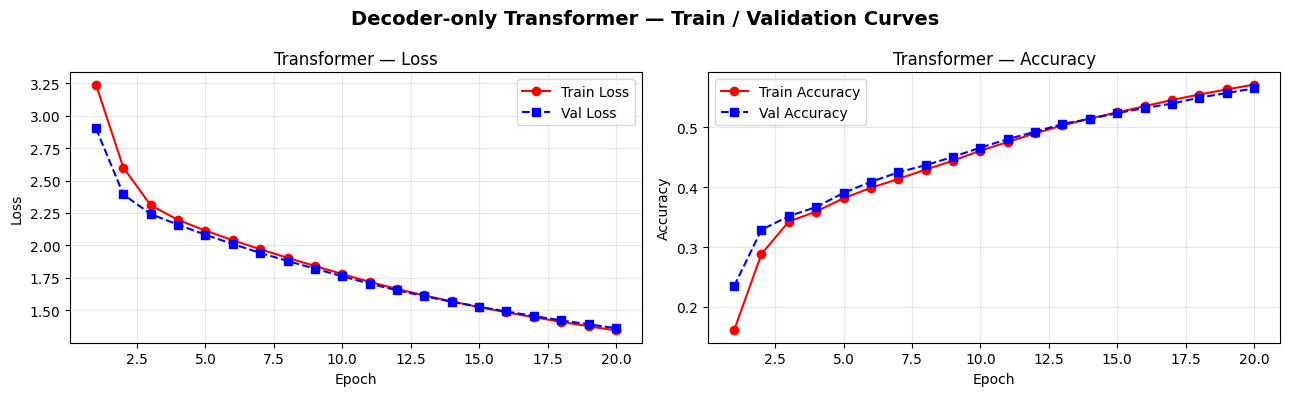

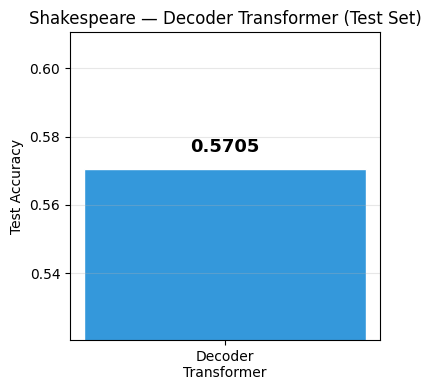

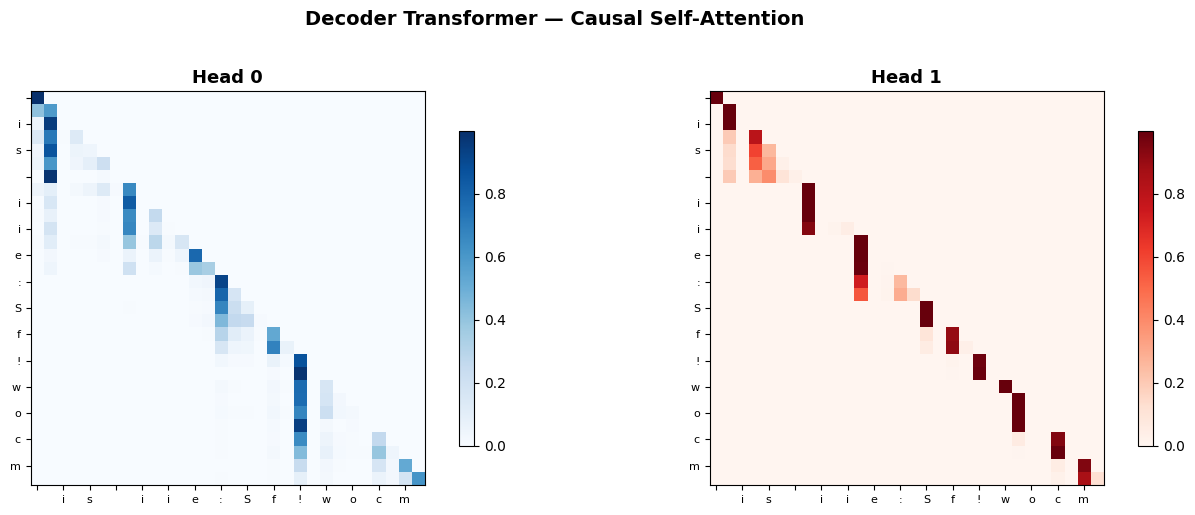


 Temperature = 0.2

[Decoder Transformer]
 it the part all the accious an evied an have the patricians helpear us an ow we a the part us him us him us an the patricians the part us the part all the part us an enot the patricious mist the patr

 Temperature = 0.5

[Decoder Transformer]
 and Citizen:
We hear af it the part all the revied on to they be heard us him, whe mart: fay an'ly an ow't the as for for for reven hear in hear sear, the accious the be acciour stay suffery mirst th

 Temperature = 1.0

[Decoder Transformer]
 us: yone howner helpl oce us armain
th Comestry are ugh
or brist fort
pethy honer strake, kind o'ly it: eour reviaccutalek.

Firstys Citizen:
Whall, hink, Let us agliciiis, to the we ne'er be done ca


In [1]:
# ========================================================
# Week 15 : Decoder-only Transformer
# Character-level Text Generation (Shakespeare)
# ========================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

SEQ_LEN     = 30
EMBED_DIM   = 32
EPOCHS      = 20
BATCH       = 32
NUM_SAMPLES = 5000
MAX_TOKENS  = 10000

# =========================================
# 1. Load Shakespeare
# =========================================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text = open(path, 'r').read()[:MAX_TOKENS]
print(f"Text length: {len(text):,} chars")

chars       = sorted(set(text))
VOCAB_SIZE  = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded     = np.array([char_to_idx[c] for c in text])
print(f"Unique chars: {VOCAB_SIZE}")

# --- Sequence pairs (Many-to-Many for Transformer) ---
X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i:i+SEQ_LEN])
    y.append(encoded[i+1:i+SEQ_LEN+1])
X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])
print(f"Sequences: {X.shape}")

# =========================================
# 2. Train / Val / Test Split  (60 / 20 / 20)
# =========================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

# =========================================
# 3. Positional Encoding
# =========================================
def get_positional_encoding(seq_len, d_model):
    pos    = np.arange(seq_len)[:, np.newaxis]
    dim    = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe     = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# =========================================
# 4. Model Definition — Decoder-only Transformer
# =========================================
class DecoderTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.pe        = get_positional_encoding(SEQ_LEN, EMBED_DIM)
        self.mha       = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=EMBED_DIM)
        self.norm1     = tf.keras.layers.LayerNormalization()
        self.ffn1      = tf.keras.layers.Dense(128, activation='relu')
        self.ffn2      = tf.keras.layers.Dense(EMBED_DIM)
        self.norm2     = tf.keras.layers.LayerNormalization()
        self.out       = tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')

    def call(self, x, return_attention=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        attn_out, attn_scores = self.mha(
            x, x, x, use_causal_mask=True, return_attention_scores=True)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ffn2(self.ffn1(x)))
        logits = self.out(x)
        return (logits, attn_scores) if return_attention else logits

model_tf = DecoderTransformer()
model_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# =========================================
# 5. Train (validation_data = Val set)
# =========================================
print("\nTraining: Decoder Transformer")
h_tf = model_tf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)



# =========================================
# 6. Final Test Evaluation (1회만)
# =========================================
test_loss, test_acc = model_tf.evaluate(X_test, y_test, verbose=0)
print(f"\nTransformer — Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# =========================================
# 7. Loss & Accuracy (Train / Val subplot)
# =========================================
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Train / Val Loss
axes[0].plot(ep, h_tf.history['loss'],     'r-o', label='Train Loss')
axes[0].plot(ep, h_tf.history['val_loss'], 'b--s', label='Val Loss')
axes[0].set(title='Transformer — Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=.3)

# Train / Val Accuracy
axes[1].plot(ep, h_tf.history['accuracy'],     'r-o', label='Train Accuracy')
axes[1].plot(ep, h_tf.history['val_accuracy'], 'b--s', label='Val Accuracy')
axes[1].set(title='Transformer — Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.suptitle('Decoder-only Transformer — Train / Validation Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


# =========================================
# 8. Final Bar Chart (Test Accuracy)
# =========================================
fig, ax = plt.subplots(figsize=(4, 4))
bar = ax.bar(['Decoder\nTransformer'], [test_acc], color='#3498db', edgecolor='white', width=0.3)
ax.text(bar[0].get_x() + bar[0].get_width()/2, test_acc + 0.005, f'{test_acc:.4f}',
        ha='center', fontweight='bold', fontsize=13)
ax.set(title='Shakespeare — Decoder Transformer (Test Set)', ylabel='Test Accuracy')
ax.set_ylim(test_acc - 0.05, test_acc + 0.04)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# =========================================
# 9. Attention Heatmap
# =========================================
sample       = X_test[:1]
_, attn      = model_tf(sample, return_attention=True)
sample_chars = [idx_to_char[i] for i in sample[0]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, cmap, head_idx, title in [
    (ax1, 'Blues', 0, 'Head 0'),
    (ax2, 'Reds',  1, 'Head 1')
]:
    scores = attn[0, head_idx].numpy()
    im     = ax.imshow(scores, cmap=cmap)
    step   = max(1, len(sample_chars) // 15)
    ticks  = range(0, len(sample_chars), step)
    labels = [sample_chars[i] for i in ticks]
    ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle('Decoder Transformer — Causal Self-Attention', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# =========================================
# 10. Temperature Generation
# =========================================
def generate_tf(seed, length=200, temperature=1.0):
    result    = list(seed)
    input_seq = [char_to_idx[c] for c in seed[-SEQ_LEN:]]
    for _ in range(length):
        x        = np.array([input_seq[-SEQ_LEN:]])
        preds    = model_tf(x, return_attention=False).numpy()[0, -1]
        preds    = np.exp(np.log(preds + 1e-8) / temperature)
        preds   /= preds.sum()
        next_idx = np.random.choice(len(preds), p=preds)
        result.append(idx_to_char[next_idx])
        input_seq.append(next_idx)
    return ''.join(result[len(seed):])

seed         = text[:SEQ_LEN]
temperatures = [0.2, 0.5, 1.0]

for t in temperatures:
    print(f"\n{'='*60}\n Temperature = {t}\n{'='*60}")
    print(f"\n[Decoder Transformer]\n{generate_tf(seed, 200, t)}")




In [4]:
# ================================================================
# Week 15 Final Exam — Decoder-only Transformer
# Character-level Next Token Prediction (Shakespeare)
#
# [Student Instructions]
#   1. Only modify the MODIFY HERE sections
#   2. Modifying any other section results in 0 points
#   3. Total parameter count MUST be <= 150,000 (auto-checked)
#   4. Before submitting: Runtime > Run all to verify your score
# ================================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ================================================================
# 0. Enter Your Student ID (ensures reproducibility)
# ================================================================
STUDENT_ID = 20241234   # <- Replace with your student ID

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

# ================================================================
# 1. Fixed Hyperparameters — DO NOT MODIFY
# ================================================================
SEQ_LEN     = 64
NUM_SAMPLES = 20_000
MAX_TOKENS  = 100_000
BATCH       = 64
EPOCHS_FULL = 50        # fixed for full-training visualization
SEEDS_EVAL  = [42, 123, 777]
MAX_PARAMS  = 150_000

# ================================================================
# 2. Data Loading — DO NOT MODIFY
# ================================================================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text        = open(path, 'r').read()[:MAX_TOKENS]
chars       = sorted(set(text))
VOCAB_SIZE  = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded     = np.array([char_to_idx[c] for c in text])

X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i : i + SEQ_LEN])
    y.append(encoded[i + 1 : i + SEQ_LEN + 1])
X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Vocab     : {VOCAB_SIZE}")
print(f"Train     : {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ================================================================
# 3. Positional Encoding — DO NOT MODIFY
# ================================================================
def get_positional_encoding(seq_len, d_model):
    pos    = np.arange(seq_len)[:, np.newaxis]
    dim    = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe     = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# ================================================================
# 4. Baseline Model — DO NOT MODIFY (reference only)
#    Single decoder block, no dropout, fixed sinusoidal PE
#    EMBED_DIM=64, FFN_DIM=256, num_heads=4
#    Measured baseline test loss: ~0.75 at 50 epochs (NUM_SAMPLES=20,000)
# ================================================================
class BaselineTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, 64)
        self.pe        = get_positional_encoding(SEQ_LEN, 64)
        self.mha       = tf.keras.layers.MultiHeadAttention(
                             num_heads=4, key_dim=64)
        self.norm1     = tf.keras.layers.LayerNormalization()
        self.ffn1      = tf.keras.layers.Dense(256, activation='relu')
        self.ffn2      = tf.keras.layers.Dense(64)
        self.norm2     = tf.keras.layers.LayerNormalization()
        self.out       = tf.keras.layers.Dense(VOCAB_SIZE,
                             activation='softmax')

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        a, _ = self.mha(x, x, x,
                        use_causal_mask=True,
                        return_attention_scores=True)
        x = self.norm1(x + a)
        x = self.norm2(x + self.ffn2(self.ffn1(x)))
        return self.out(x)

# ================================================================
# 5. MODIFY HERE — Your Optimized Model
#
#    Optimization hints (choose any combination):
#      (a) Increase number of decoder blocks  (num_layers)
#      (b) Replace Sinusoidal PE with Learnable PE
#      (c) Add Dropout for regularization
#      (d) Change FFN activation: relu -> gelu
#      (e) Add a Learning Rate schedule
#      (f) Adjust embed_dim or ffn_dim within parameter budget
#
#    Hard constraints (auto-checked):
#      - Total trainable parameters <= 150,000
#      - Causal mask MUST be used  (use_causal_mask=True)
#      - Positional Encoding MUST be included
# ================================================================

class StudentTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # START modifying below

        EMBED_DIM = 64
        FFN_DIM   = 256

        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.pe        = get_positional_encoding(SEQ_LEN, EMBED_DIM)
        self.mha       = tf.keras.layers.MultiHeadAttention(
                             num_heads=4, key_dim=EMBED_DIM)
        self.norm1     = tf.keras.layers.LayerNormalization()
        self.ffn1      = tf.keras.layers.Dense(FFN_DIM, activation='relu')
        self.ffn2      = tf.keras.layers.Dense(EMBED_DIM)
        self.norm2     = tf.keras.layers.LayerNormalization()
        self.out       = tf.keras.layers.Dense(VOCAB_SIZE,
                             activation='softmax')

        # STOP modifying above

    def call(self, x, training=False):
        # START modifying below

        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        a, _ = self.mha(x, x, x,
                        use_causal_mask=True,       # DO NOT REMOVE
                        return_attention_scores=True)
        x = self.norm1(x + a)
        x = self.norm2(x + self.ffn2(self.ffn1(x)))
        return self.out(x)

        # STOP modifying above

# ================================================================
# 6. Optimizer and Epochs — YOU MAY CHANGE THIS
# ================================================================
# START modifying below

EPOCHS_STUDENT = 50     # feel free to increase (e.g. 80, 100)
                        # more epochs → better convergence → lower loss

def get_optimizer():
    return tf.keras.optimizers.Adam(learning_rate=1e-3)
    # Example: cosine decay schedule
    # lr = tf.keras.optimizers.schedules.CosineDecay(1e-3, decay_steps=1500)
    # return tf.keras.optimizers.Adam(lr)

# STOP modifying above

# ================================================================
# 7. Parameter Count Check — DO NOT MODIFY
# ================================================================
def count_params(model, input_shape=(1, SEQ_LEN)):
    model(tf.zeros(input_shape, dtype=tf.int32))
    total = sum(tf.size(v).numpy() for v in model.trainable_variables)
    return total

student_model = StudentTransformer()
n_params = count_params(student_model)
print(f"\nTotal parameters: {n_params:,}")
assert n_params <= MAX_PARAMS, (
    f"[ERROR] Parameter limit exceeded: {n_params:,} > {MAX_PARAMS:,} — cannot grade")
print("[OK] Parameter constraint passed")

# ================================================================
# 8. Full Training (1 run) — for learning curve visualization
# ================================================================
print(f"\n{'='*50}")
print(f"[Full Training] epochs={EPOCHS_STUDENT}")
print(f"{'='*50}")

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

student_model = StudentTransformer()
student_model.compile(
    optimizer=get_optimizer(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = student_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_STUDENT,
    batch_size=BATCH,
    verbose=1
)

# ================================================================
# 9. Train / Val Curve — DO NOT MODIFY
# ================================================================
ep = range(1, EPOCHS_STUDENT + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ep, history.history['loss'],     'r-o',  label='Train', markersize=3)
axes[0].plot(ep, history.history['val_loss'], 'b--s', label='Val',   markersize=3)
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(ep, history.history['accuracy'],     'r-o',  label='Train', markersize=3)
axes[1].plot(ep, history.history['val_accuracy'], 'b--s', label='Val',   markersize=3)
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.suptitle('Student Model — Train / Validation Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_val_curve.png', dpi=120)
plt.show()

# ================================================================
# 10. Auto Grading — 3-run repeated evaluation — DO NOT MODIFY
#     Each run: reinitialize -> train EPOCHS_STUDENT -> evaluate test loss
#     Final score is based on the BEST (lowest) loss among 3 runs.
# ================================================================
print(f"\n{'='*50}")
print(f"[Auto Grading] Starting {len(SEEDS_EVAL)}-run evaluation")
print(f"  Each run: reinitialize -> {EPOCHS_STUDENT} epochs -> test loss")
print(f"  Score based on: best (lowest) loss of 3 runs")
print(f"{'='*50}")

eval_losses = []

for i, seed in enumerate(SEEDS_EVAL):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    m = StudentTransformer()
    m.compile(
        optimizer=get_optimizer(),
        loss='sparse_categorical_crossentropy'
    )
    m.fit(X_train, y_train,
          epochs=EPOCHS_STUDENT,
          batch_size=BATCH,
          verbose=0)

    result = m.evaluate(X_test, y_test, verbose=0)
    loss = result[0] if isinstance(result, (list, tuple)) else result
    eval_losses.append(loss)
    print(f"  Run {i+1} (seed={seed}): test loss = {loss:.4f}")

best_loss = float(np.min(eval_losses))
mean_loss = float(np.mean(eval_losses))
std_loss  = float(np.std(eval_losses))
# ================================================================
# 11. Score Calculation — DO NOT MODIFY
#
#     Baseline measured: B = 0.75
#     (NUM_SAMPLES=20,000, EPOCHS=50, single decoder block)
# ================================================================

print(f"\n{'='*50}")
print(f"  AUTO GRADING RESULT")
print(f"{'='*50}")
print(f"  Student ID          : {STUDENT_ID}")
print(f"  Total parameters    : {n_params:,}")
print(f"  Epochs (student)    : {EPOCHS_STUDENT}")
print(f"  Run 1/2/3 losses    : {eval_losses[0]:.4f} / {eval_losses[1]:.4f} / {eval_losses[2]:.4f}")
print(f"  Best test loss      : {best_loss:.4f}  (mean: {mean_loss:.4f} +- {std_loss:.4f})")


Vocab     : 61
Train     : 12000 | Val: 4000 | Test: 4000

Total parameters: 107,581
[OK] Parameter constraint passed

[Full Training] epochs=50
Epoch 1/50
 69/188 ━━━━━━━━━━━━━━━━━━━━ 26s 224ms/step - accuracy: 0.1391 - loss: 3.5823

KeyboardInterrupt: 